In [40]:
import os 
import copy
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import gridspec

import pandas as pd

In [7]:
os.chdir('/Users/chenxizhou/Dropbox/code_package/dekef')

true_data = np.load('data/geyser.npy').astype(np.float64)
df = copy.deepcopy(true_data[:, 0]).reshape(-1, 1)
data_waiting = df[df != 108.0]
contam_pt = 120.
data = np.append(data_waiting, contam_pt)

xlimit = (1., 310.)
ylimit = (-0.001, 0.0701)
plot_pts_cnt = 3000
new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

contam_weight = 1e-3

kernel_type = 'gaussian_poly2'
bw = 7.0
log_pen_param = -3.

var_name = 'additional observation'
method = 'ML'

seed_no = 1

ml_folder = (f'data/PenML-ContamData={contam_pt}-bw={bw}-' + 
             f'kernel={kernel_type}-plotdomain={xlimit}-plotcnts={plot_pts_cnt}-' + 
             f'seed={seed_no}')

sm_folder = (f'data/PenSM-FinKEF-ContamData={contam_pt}-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}')

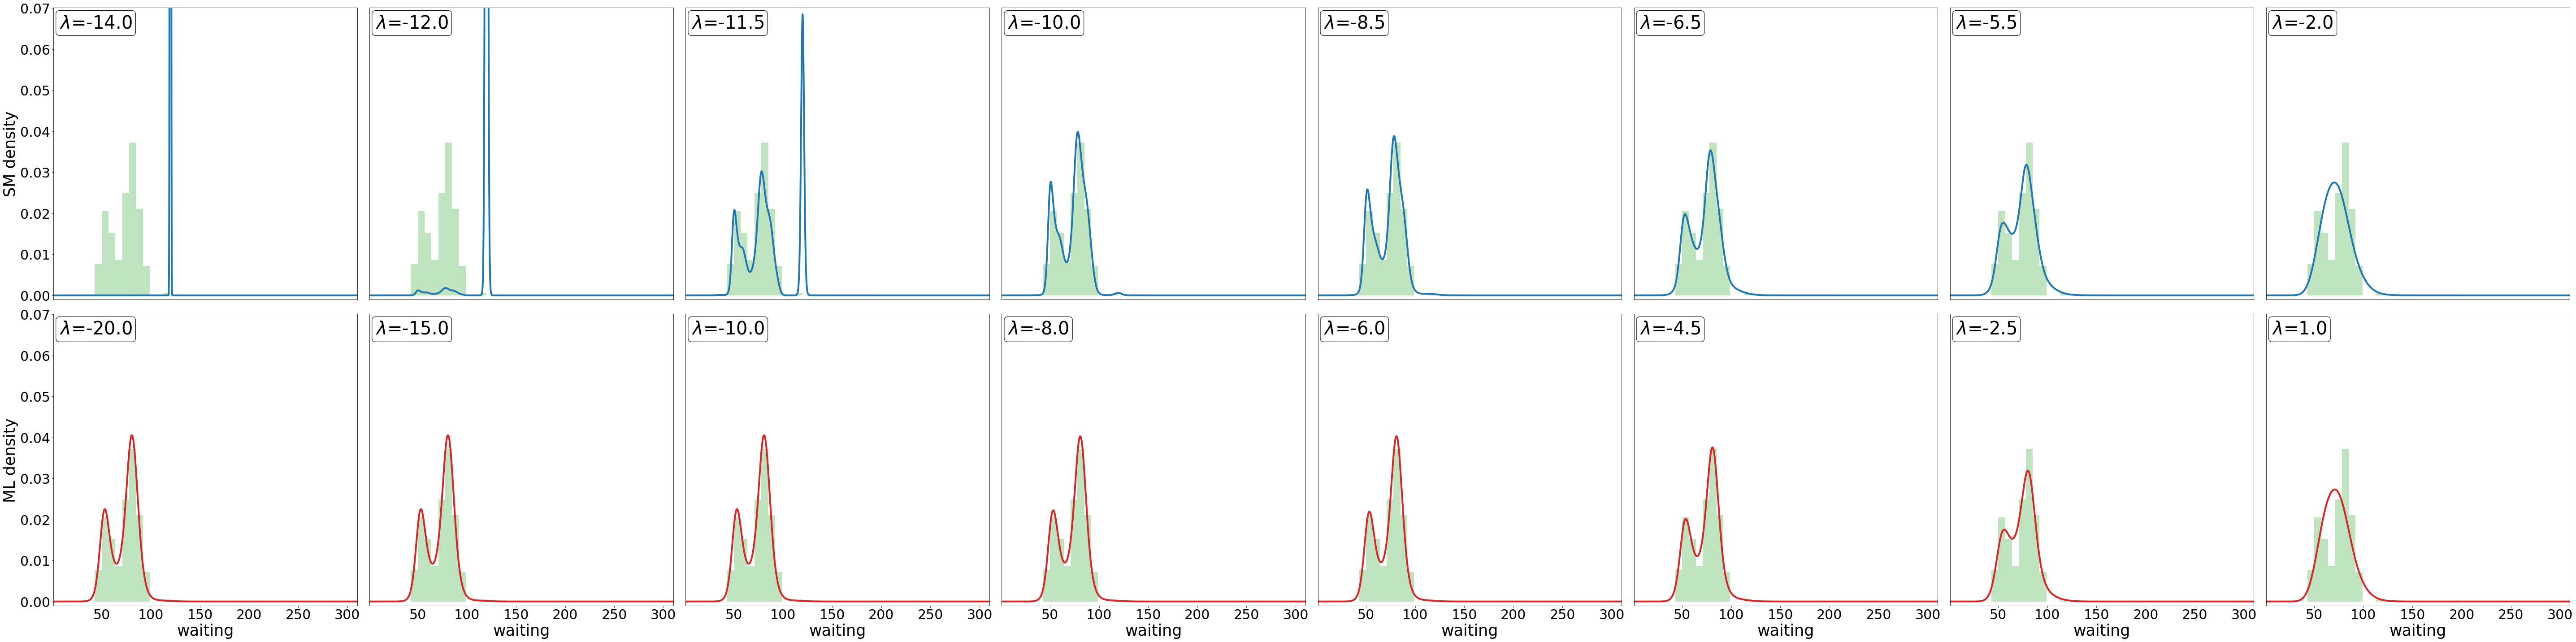

In [54]:
fig = plt.figure(constrained_layout=False)

fig.set_figheight(20)
fig.set_figwidth(80)
ncols = 8
nrows = 2
linewidth = 4.0
var_name = 'waiting'

label_fontsize = 35
tick_fontsize = 30
info_fontsize = 40

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)
sm_logpen_list = [-14., -12., -11.5, -10., -8.5, -6.5, -5.5, -2.]
ml_logpen_list = [-20., -15., -10., -8., -6., -4.5, -2.5, 1.]

for i in range(ncols): 
    
    ax = fig.add_subplot(spec[0, i])
    file_name_den = f'/logpenparam={sm_logpen_list[i]}-densityvals-newdata.npy'
    sm_den = np.load(sm_folder + file_name_den)

    ax.plot(new_data.flatten(), sm_den.flatten(), color = 'tab:blue', linewidth = linewidth)
    plt.hist(data, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    
    if i == 0: 
        ax.set_ylabel(r'SM density', fontsize = label_fontsize)
    ax.set_xlim(xlimit)
    ax.set_ylim(ylimit)
    # ax.axvline(108., 0, 1, ls = '--', color = 'tab:purple', alpha = 0.5)
    # ax.tick_params(axis = 'both', labelsize = fontsize)
    # ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = scilimits)
    ax.tick_params(axis = 'both', labelsize = tick_fontsize)
    ax.set_xticks([])
    if i != 0: 
        ax.set_yticks([])
    #ax.set_xlabel(var_name, fontsize = fontsize)

    info = r"$\lambda$={bw}".format(bw = sm_logpen_list[i])

    ax.text(0.02, 0.978,
            info,
            fontsize = info_fontsize,
            multialignment = 'left',
            horizontalalignment = 'left',
            verticalalignment = 'top',
            transform = ax.transAxes,
            bbox = {'facecolor': 'none',
                    'boxstyle': 'Round, pad=0.2'})

for i in range(ncols): 
    
    ax = fig.add_subplot(spec[1, i])
    file_name_den = f'/logpenparam={ml_logpen_list[i]}-densityvals-newdata.npy'
    ml_den = np.load(ml_folder + file_name_den)

    ax.plot(new_data.flatten(), ml_den.flatten(), color = 'tab:red', linewidth = linewidth)
    plt.hist(data, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    
    if i == 0: 
        ax.set_ylabel(r'ML density', fontsize = label_fontsize)
    ax.set_xlim(xlimit)
    ax.set_ylim(ylimit)
    # ax.axvline(108., 0, 1, ls = '--', color = 'tab:purple', alpha = 0.5)
    # ax.tick_params(axis = 'both', labelsize = fontsize)
    # ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = scilimits)
    ax.tick_params(axis = 'both', labelsize = tick_fontsize)
    ax.set_xlabel(var_name, fontsize = label_fontsize)
    if i != 0: 
        ax.set_yticks([])
    #ax.set_xlabel(var_name, fontsize = fontsize)

    info = r"$\lambda$={bw}".format(bw = ml_logpen_list[i])

    ax.text(0.02, 0.978,
            info,
            fontsize = info_fontsize,
            multialignment = 'left',
            horizontalalignment = 'left',
            verticalalignment = 'top',
            transform = ax.transAxes,
            bbox = {'facecolor': 'none',
                    'boxstyle': 'Round, pad=0.2'})


plt.tight_layout()

plt.savefig('plots/ML-SM-density-comparison.pdf')

In [32]:
from dekef.base_density import *
base_density = BasedenGamma(np.load('data/geyser.npy').astype(np.float64)[:, 0])
log_base_density = np.log(base_density.baseden_eval(new_data = new_data.reshape(-1, 1)).flatten())

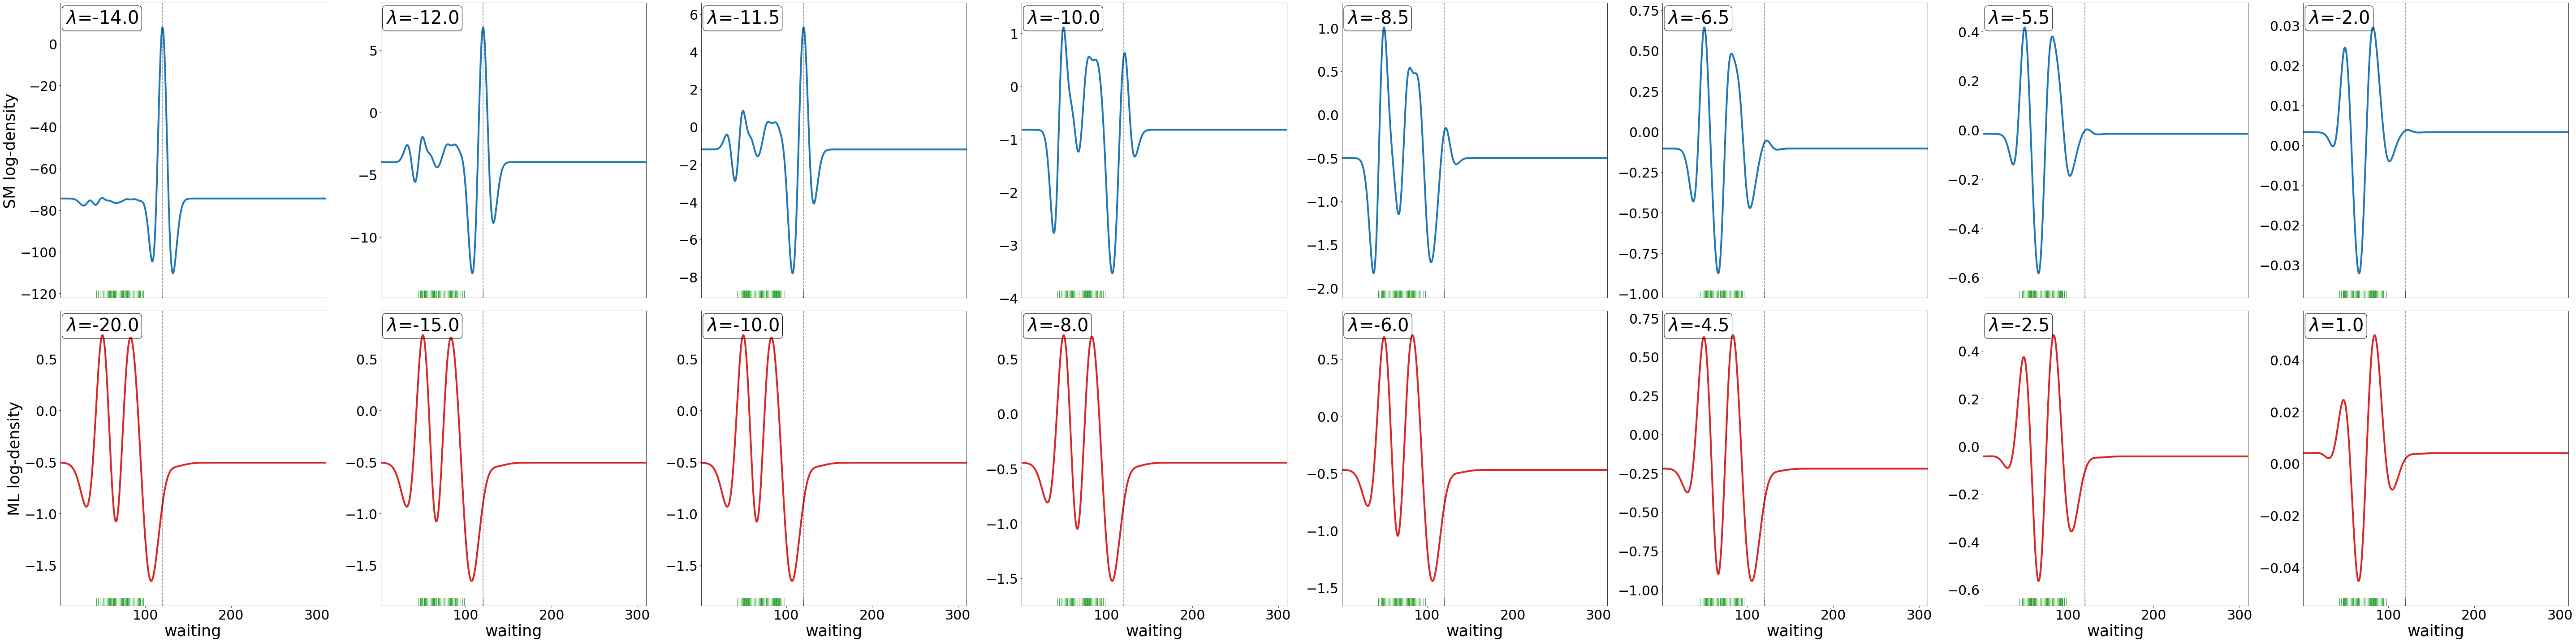

In [55]:
fig = plt.figure(constrained_layout=False)

fig.set_figheight(20)
fig.set_figwidth(80)
ncols = 8
nrows = 2
linewidth = 4.0
var_name = 'waiting'

label_fontsize = 35
tick_fontsize = 30
info_fontsize = 40

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)
sm_logpen_list = [-14., -12., -11.5, -10., -8.5, -6.5, -5.5, -2.]
ml_logpen_list = [-20., -15., -10., -8., -6., -4.5, -2.5, 1.]

for i in range(ncols): 
    
    ax = fig.add_subplot(spec[0, i])
    file_name_den = f'/logpenparam={sm_logpen_list[i]}-densityvals-newdata.npy'
    sm_den = np.load(sm_folder + file_name_den)
    sm_den = np.log(sm_den.flatten()) - log_base_density

    ax.plot(new_data.flatten(), sm_den.flatten(), color = 'tab:blue', linewidth = linewidth)
    sns.rugplot(pd.Series(data.flatten()), ax = ax, color = 'tab:green')
    # sns.rugplot(pd.Series([contam_pt]), ax = ax, color = 'black')
    ax.axvline(contam_pt, 0, 1, ls = '--', color = 'black', alpha = 0.5)
    
    if i == 0: 
        ax.set_ylabel(r'SM log-density', fontsize = label_fontsize)
    ax.set_xlim(xlimit)
    # ax.set_ylim(ylimit)
    # ax.axvline(108., 0, 1, ls = '--', color = 'tab:purple', alpha = 0.5)
    # ax.tick_params(axis = 'both', labelsize = fontsize)
    # ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = scilimits)
    ax.tick_params(axis = 'both', labelsize = tick_fontsize)
    ax.set_xticks([])
    #ax.set_xlabel(var_name, fontsize = fontsize)

    info = r"$\lambda$={bw}".format(bw = sm_logpen_list[i])

    ax.text(0.02, 0.978,
            info,
            fontsize = info_fontsize,
            multialignment = 'left',
            horizontalalignment = 'left',
            verticalalignment = 'top',
            transform = ax.transAxes,
            bbox = {'facecolor': 'none',
                    'boxstyle': 'Round, pad=0.2'})

for i in range(ncols): 
    
    ax = fig.add_subplot(spec[1, i])
    file_name_den = f'/logpenparam={ml_logpen_list[i]}-densityvals-newdata.npy'
    ml_den = np.load(ml_folder + file_name_den)
    ml_den = np.log(ml_den.flatten()) - log_base_density

    ax.plot(new_data.flatten(), ml_den.flatten(), color = 'tab:red', linewidth = linewidth)
    sns.rugplot(pd.Series(data.flatten()), ax = ax, color = 'tab:green')
    # sns.rugplot(pd.Series([contam_pt]), ax = ax, color = 'black')
    ax.axvline(contam_pt, 0, 1, ls = '--', color = 'black', alpha = 0.5)
    
    if i == 0: 
        ax.set_ylabel(r'ML log-density', fontsize = label_fontsize)
    ax.set_xlim(xlimit)
    # ax.set_ylim(ylimit)
    # ax.axvline(108., 0, 1, ls = '--', color = 'tab:purple', alpha = 0.5)
    # ax.tick_params(axis = 'both', labelsize = fontsize)
    # ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = scilimits)
    ax.tick_params(axis = 'both', labelsize = tick_fontsize)
    # ax.set_xticks([])
    
    ax.set_xlabel(var_name, fontsize = label_fontsize)

    info = r"$\lambda$={bw}".format(bw = ml_logpen_list[i])

    ax.text(0.02, 0.978,
            info,
            fontsize = info_fontsize,
            multialignment = 'left',
            horizontalalignment = 'left',
            verticalalignment = 'top',
            transform = ax.transAxes,
            bbox = {'facecolor': 'none',
                    'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig('plots/ML-SM-logdensity-comparison.pdf')